# 05 – CPM Reflection

This tutorial demonstrates ptychographic reconstruction in reflection geometry using a two-layer sample measured at 708 nm. It shows how to set up the `aPIE` engine for datasets acquired at a tilt angle.

**What you'll learn:**

- How to configure ptychography for reflection geometry
- How to use the tilt angle parameter (`theta`) in the data
- How to run `aPIE` for angle-correcting reconstruction

!!! note "Dataset"
    The dataset (`TwoLayer_bin4.hdf5`) is downloaded automatically into the `example_data/` folder at the project root the first time you run the notebook. If the file already exists it is not re-downloaded.

!!! tip "Prerequisites"
    Complete [01 – CPM Simulation](tutorial_CPM_sim.ipynb) before this tutorial.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import h5py

In [2]:
# import the PtyLab module
import PtyLab
from PtyLab import ExperimentalData
from PtyLab import Reconstruction
from PtyLab import Monitor
from PtyLab import Params
from PtyLab import Engines

The dataset (`TwoLayer_bin4.hdf5`) is downloaded automatically into the `example_data/` folder at the project root the first time you run the next cell. If the file already exists it is not re-downloaded.

In [3]:
from PtyLab.io import getExampleDataFolder
import urllib.request

fileName = "TwoLayer_bin4.hdf5"
filePath = getExampleDataFolder() / fileName

if not filePath.exists():
    print(f"Downloading {fileName}...")
    urllib.request.urlretrieve(
        "https://ndownloader.figshare.com/files/28720086",
        filePath,
    )
    print("Download complete.")
else:
    print(f"{fileName} found, skipping download.")

TwoLayer_bin4.hdf5 found, skipping download.


Step 2: Initialize the ExperimentalData class 

In [4]:
# Initialize the ExperimentalData using the filePath, and choose the operation Mode (default is 'CPM')
experimentalData = ExperimentalData(filePath, operationMode="CPM")
# show measured ptychogram in log scale. Need to close the window to continue
# experimentalData.showPtychogram()

Found encoder with shape (202, 2)


Step 3: Initialize the Monitor class and set properties

In [5]:
# Initialize the Monitor class
monitor = Monitor()
# Set monitor properties
monitor.figureUpdateFrequency = 1
monitor.objectPlot = "complex"  # complex abs angle
monitor.verboseLevel = "high"  # high: plot two figures, low: plot only one figure
monitor.probeZoom = 1  # control probe plot FoV
monitor.objectZoom = 2  # control object plot FoV
monitor.objectPlotContrast = (
    0.8  # control object plot contrast, 0-1, higher constrast with smaller number
)
monitor.probePlotContrast = (
    0.5  # control probe plot contrast, 0-1, higher constrast with smaller number
)

/mnt/home/shantanu/projects/PtyLab.py/PtyLab/Monitor/Monitor.py:178: UserWarning: For faster update of the reconstruction plot, set `monitor.figureUpdateFrequency = 5` or higher.
  warnings.warn(
/mnt/home/shantanu/projects/PtyLab.py/PtyLab/Monitor/Monitor.py:191: UserWarning: For diffraction data plot, preferably use an interactive matplotlib backend or set `monitor.verboseLevel = "low"`. 
  warnings.warn(


Step 4: Initialize the Params class and set properties

In [6]:
# Initialize the Params class
params = Params()
# Set params properties
params.gpuSwitch = True
params.positionOrder = "random"  # 'sequential' or 'random'
params.propagator = (
    "Fraunhofer"  # Fraunhofer Fresnel ASP scaledASP polychromeASP scaledPolychromeASP
)
params.probePowerCorrectionSwitch = True
params.comStabilizationSwitch = True
params.fftshiftSwitch = False
params.backgroundModeSwitch = True
params.intensityConstraint = "standard"

INFO:GPU:cupy and CUDA available, switching to GPU


Step 5: Initialize the Reconstruction class and set properties

In [7]:
# Initialize the Reconstruction class
reconstruction = Reconstruction(experimentalData, params)
# reconstruction.No = 2**11

# choose the inital format of the probe and object, and initialize them
reconstruction.initialProbe = "circ"
reconstruction.initialObject = "ones"
reconstruction.initializeObjectProbe()

# Optional: customize initial probe quadratic phase:
# since we know our beam is divergent, we add a diverging wavefront to the initial beam
reconstruction.probe = reconstruction.probe * np.exp(
    1.0j
    * 2
    * np.pi
    / reconstruction.wavelength
    * (reconstruction.Xp**2 + reconstruction.Yp**2)
    / (3 * 6e-3)
)

INFO:Reconstruction:Copying attribute wavelength
INFO:Reconstruction:Copying attribute dxd
INFO:Reconstruction:Copying attribute theta
INFO:Reconstruction:Copying attribute spectralDensity
INFO:Reconstruction:Copying attribute entrancePupilDiameter
INFO:Reconstruction:Initial object set to ones
INFO:Reconstruction:Initial probe set to circ


Step 6: Choose the engine, set the properties, and do reconstruction

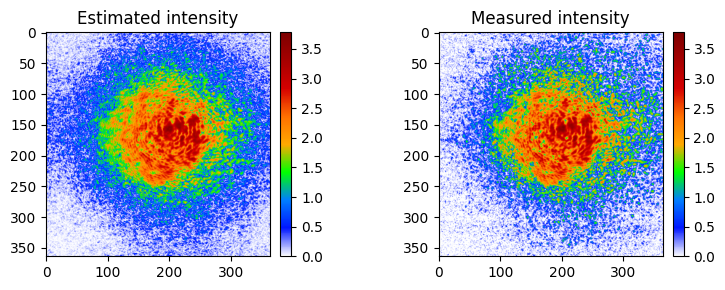

                                                       
iteration: 299                                         
error: 57.5                                            
estimated linear overlap: 86.1 %                       
estimated area overlap: 77.3 %                         
mPIE: 100%|██████████| 300/300 [02:16<00:00,  2.20it/s]

INFO:mPIE:switch to cpu


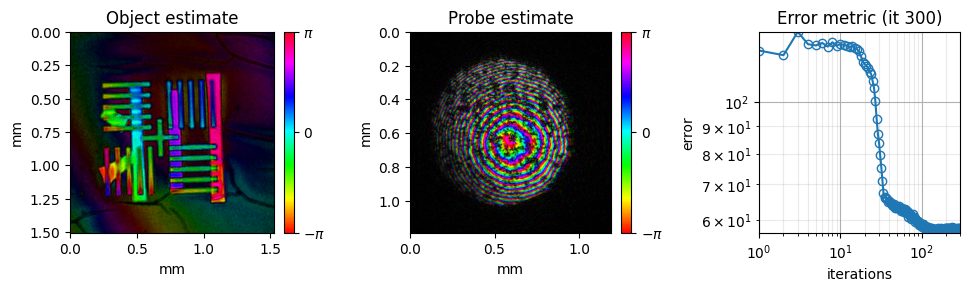

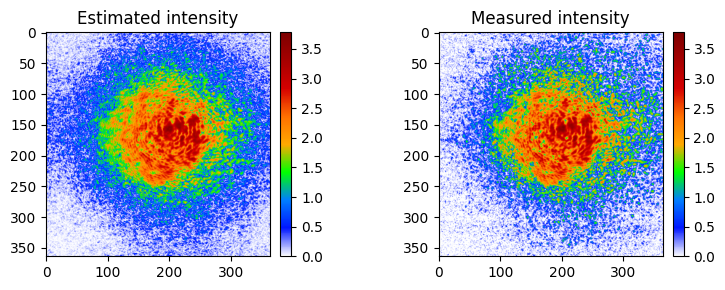

In [8]:
# Choose mPIE engine
mPIE = Engines.mPIE(reconstruction, experimentalData, params, monitor)
mPIE.numIterations = 300
mPIE.betaProbe = 0.25
mPIE.betaObject = 0.25
mPIE.reconstruct()

In [9]:
## now save the data
# reconstruction.saveResults(fileName+'_reconstruction.hdf5')